<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_JTWPA_Simulation_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!uv pip install cupy-cuda12x matplotlib numpy

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 132ms


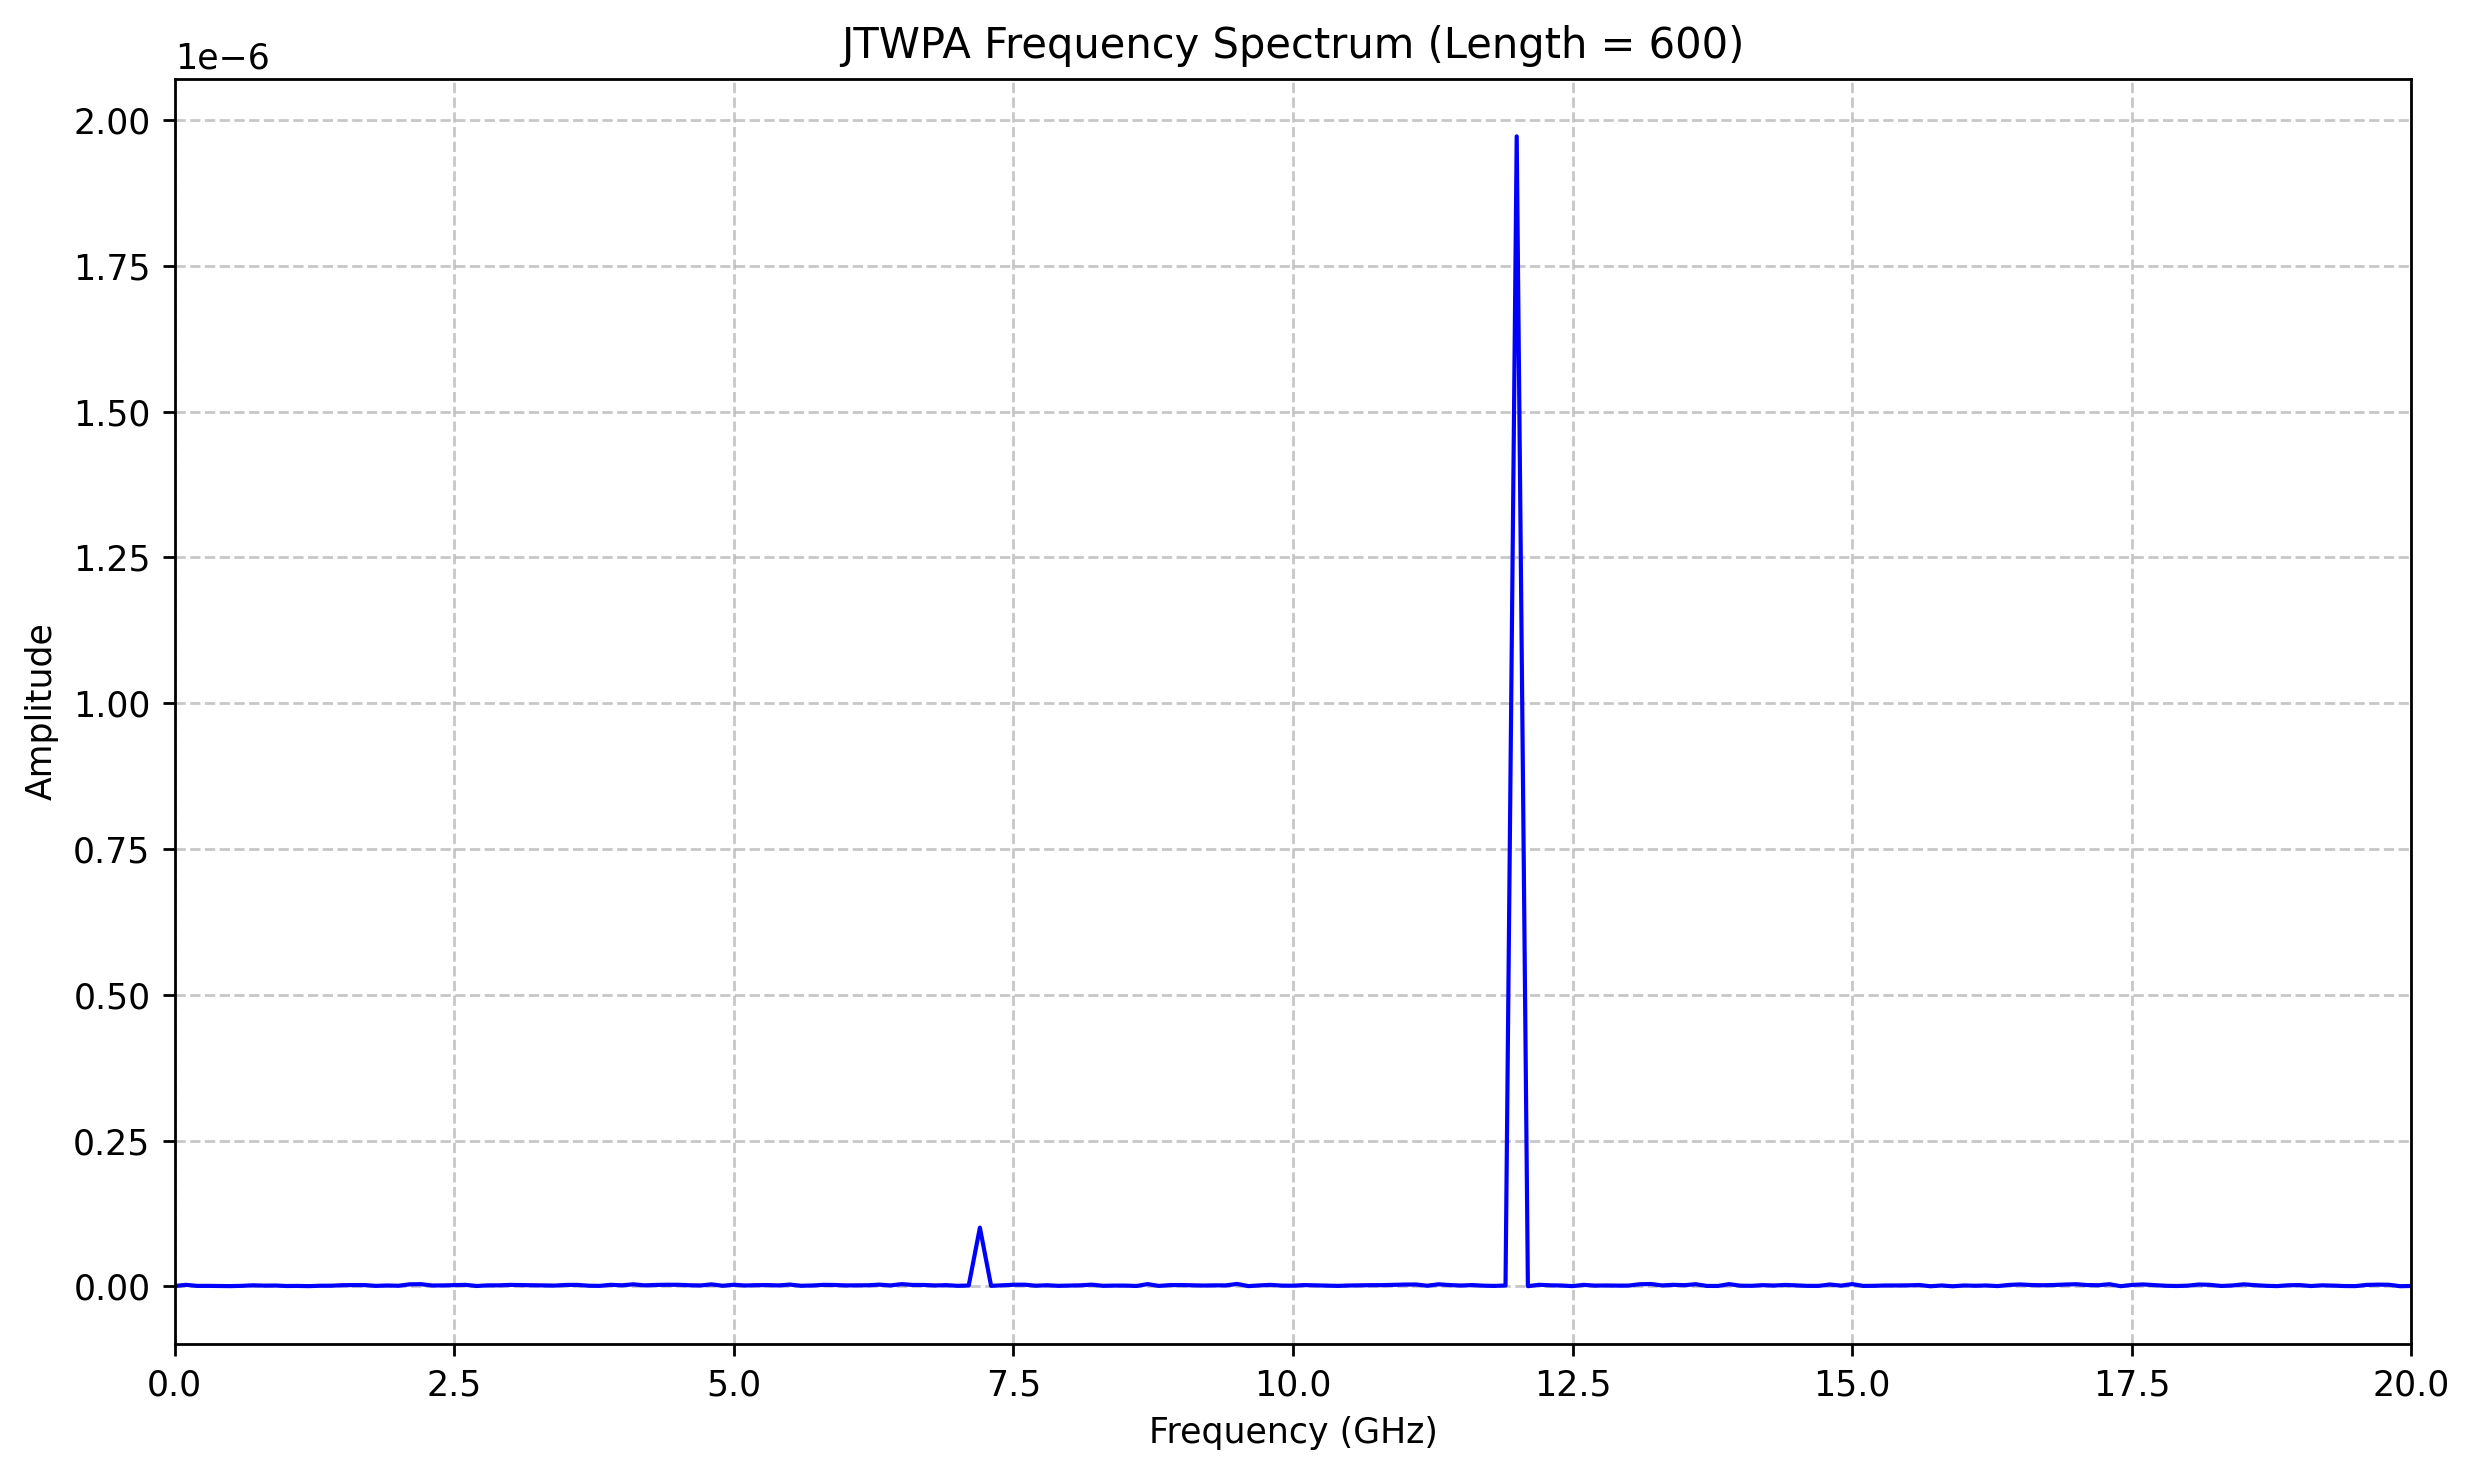

In [2]:
"""
JTWPA Circuit Generation and GPU-Accelerated FFT Analysis.

This module generates a SPICE netlist for a Josephson Traveling Wave
Parametric Amplifier (JTWPA), executes the simulation, and processes
the time-domain output using GPU-accelerated Fast Fourier Transforms (FFT).
"""

import os
import subprocess
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ==============================================================================
# CONTROL KNOBS (Parameter Adjustment)
# ==============================================================================
# Circuit parameters
START_LENGTH = 500
END_LENGTH = 601
TIMESTEP_SEC = 1e-12  # 1 picosecond (1p in SPICE)

# File paths
CIRCUIT_FILE = "run5.cir"
OUTPUT_DATA_FILE = "outf5.txt"
RESULT_DATA_FILE = "result5.txt"

# Matplotlib configuration for Colab rendering
matplotlib.rcParams['figure.dpi'] = 250
matplotlib.rcParams['figure.figsize'] = (10, 6)
# ==============================================================================

def generate_spice_netlist(length: int, filename: str) -> None:
    """
    Generates the SPICE netlist for the JTWPA circuit of a specific length.

    Args:
        length (int): The number of unit cells in the JTWPA transmission line.
        filename (str): The destination file path for the generated netlist.
    """
    # Initialize node indices
    idx_2 = 2
    idx_125002 = 125002
    idx_555555 = 555555
    idx_1 = 1
    idx_5001 = 5001

    with open(filename, "w") as outfile:
        outfile.write("*jj bias sweep\n")
        outfile.write(".model jj0 jj(rtype=0, icrit=5uA, cap=60.0000fF)\n")
        outfile.write(
            "Iin 1 0 (sin(0 1.97uA 12.0000GHz 9ns 0 0) + "
            "sin(0 0.1uA 7.2000GHz 9ns 0 0))\n"
        )

        for i in range(length):
            line1 = f"Idc{idx_2} 0 {idx_125002} pwl(0 0uA 5ns 14.0680uA)\n"
            line2 = f"Lflux{idx_2} {idx_125002} 0 57.0000pH\n"
            line5 = f"Lg{idx_2} {idx_1} {idx_555555} 57pH\n"
            line3 = f"K{idx_2} Lg{idx_2} Lflux{idx_2} 1\n"
            line8 = f"Cg{idx_2} {idx_1} 0 50fF\n"
            line6 = f"B{idx_2} {idx_1} {idx_555555} {idx_5001} jj0\n"
            line10 = f"Vout{idx_1} {idx_555555} {idx_2} DC 0\n"
            line7 = f"Cgg{idx_2} {idx_2} 0 50fF\n"

            if i == 0:
                outfile.write(line8)
            else:
                outfile.writelines([
                    line1, line2, line5, line3, line6, line10, line7, "\n"
                ])

            idx_2 += 1
            idx_125002 += 1
            idx_1 += 1
            idx_5001 += 1
            idx_555555 += 1

        outfile.write(f"Rtermend {length} 0 50Ohm\n")
        outfile.write(".control \n")
        outfile.write("set maxdata = 2e9\n")
        outfile.write("tran 1p 22.0000n 12n uic\n")
        outfile.write(f"print /n i(Vout{length - 100}) > {OUTPUT_DATA_FILE}\n")
        outfile.write("set noaskquit\n")
        outfile.write("quit\n")
        outfile.write(".endc\n")

def perform_gpu_fft(time_domain_data: cp.ndarray, time_step: float) -> tuple:
    """
    Computes the single-sided amplitude spectrum using CuPy for GPU acceleration.

    Args:
        time_domain_data (cp.ndarray): The 1D array of time-domain signal values.
        time_step (float): The sampling interval in seconds.

    Returns:
        tuple: A tuple containing the frequency array and the single-sided
               amplitude spectrum array (both as cp.ndarray).
    """
    n = len(time_domain_data)

    # Compute the full FFT on the GPU
    fft_result = cp.fft.fft(time_domain_data)

    # Compute the two-sided spectrum (P2) and single-sided spectrum (P1)
    p2 = cp.abs(fft_result / n)
    p1 = p2[0:(n // 2) + 1].copy()

    # Multiply internal values by 2 to conserve power
    # (excluding the DC component and the Nyquist frequency)
    p1[1:-1] = 2 * p1[1:-1]

    # Generate the frequency axis
    freq = cp.fft.rfftfreq(n, d=time_step)

    return freq, p1

def main():
    """
    Main orchestration function to sweep JTWPA lengths, execute SPICE,
    perform GPU FFTs, and render the final spectral plot.
    """
    # Clear previous results if they exist
    if os.path.exists(RESULT_DATA_FILE):
        os.remove(RESULT_DATA_FILE)

    final_freq = None
    final_p1 = None

    for current_length in range(START_LENGTH, END_LENGTH):
        # 1. Generate the circuit file
        generate_spice_netlist(current_length, CIRCUIT_FILE)

        # 2. Execute WRSpice (Mock fallback included for standard Colab)
        try:
            subprocess.run(["wrspice", CIRCUIT_FILE], check=True, capture_output=True)
        except FileNotFoundError:
            # Fallback: Generate dummy sinusoidal data representing the SPICE output
            # Consists of 12GHz and 7.2GHz components with noise to test the FFT
            t_dummy = np.arange(0, 10e-9, TIMESTEP_SEC)
            dummy_signal = (1.97e-6 * np.sin(2 * np.pi * 12e9 * t_dummy) +
                            0.1e-6 * np.sin(2 * np.pi * 7.2e9 * t_dummy) +
                            np.random.normal(0, 1e-7, len(t_dummy)))
            np.savetxt(OUTPUT_DATA_FILE, dummy_signal)

        # 3. Read data and transfer to GPU
        with open(OUTPUT_DATA_FILE, "r") as f:
            fft_input_cpu = np.array([float(line.strip()) for line in f if line.strip()])

        # Push array to GPU memory
        fft_input_gpu = cp.asarray(fft_input_cpu)

        # 4. Process FFT
        freq_gpu, p1_gpu = perform_gpu_fft(fft_input_gpu, TIMESTEP_SEC)

        # Pull processed arrays back to CPU memory for saving/plotting
        freq_cpu = cp.asnumpy(freq_gpu)
        p1_cpu = cp.asnumpy(p1_gpu)

        # 5. Append to result file
        with open(RESULT_DATA_FILE, "a") as result_file:
            result_file.write(f"{current_length} ")
            p1_str = " ".join(map(str, p1_cpu))
            result_file.write(f"{p1_str}\n")

        # Store the last iteration's results for plotting
        if current_length == END_LENGTH - 1:
            final_freq = freq_cpu
            final_p1 = p1_cpu

    # 6. Render the Plot natively in Colab (No saving)
    if final_freq is not None and final_p1 is not None:
        plt.figure()
        # Convert frequencies to GHz for readability
        plt.plot(final_freq / 1e9, final_p1, color='blue', linewidth=1.2)
        plt.title(f"JTWPA Frequency Spectrum (Length = {END_LENGTH - 1})")
        plt.xlabel("Frequency (GHz)")
        plt.ylabel("Amplitude")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xlim(0, 20) # Focusing on the relevant 0-20 GHz band
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()

In [7]:
!uv pip install cupy-cuda12x ipywidgets matplotlib numpy

Using Python 3.12.13 environment at: /usr
Resolved 92 packages in 340ms
Prepared 1 package in 104ms
Installed 1 package in 25ms
 + jedi==0.19.2


In [9]:
"""
GPU-Accelerated Interactive JTWPA Wave Propagation Simulator.

This module uses CuPy to compute the spatial wave propagation and
parametric gain of a signal interacting with a pump wave across
distributed Josephson Junction cells. The results are rendered
interactively using ipywidgets in Google Colab.
"""

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from ipywidgets import interact, FloatSlider, IntSlider

# ==============================================================================
# CONTROL KNOBS (Parameter Adjustment)
# ==============================================================================
# Matplotlib configuration for Colab rendering
matplotlib.rcParams['figure.dpi'] = 250
matplotlib.rcParams['figure.figsize'] = (12, 6)

# Physics constants and empirical scaling factors for visualization
NONLINEAR_COUPLING_FACTOR = 0.0015  # Dictates how strongly the pump amplifies the signal
PUMP_FREQ_GHZ = 12.0
SIGNAL_FREQ_GHZ = 7.2
WAVE_VELOCITY = 1e8                 # Assumed phase velocity in the transmission line (m/s)
CELL_LENGTH = 10e-6                 # Physical length of one unit cell (meters)
# ==============================================================================

def compute_wave_states_gpu(
    num_cells: int,
    pump_amp: float,
    signal_amp: float,
    time_ns: float
) -> tuple:
    """
    Computes the instantaneous spatial waveforms for the pump and signal
    along the JTWPA using GPU acceleration.

    Args:
        num_cells (int): Total number of unit cells.
        pump_amp (float): Input amplitude of the pump wave (uA).
        signal_amp (float): Input amplitude of the signal wave (uA).
        time_ns (float): Current simulation time in nanoseconds.

    Returns:
        tuple: CPU-bound numpy arrays containing the spatial axis,
               pump waveform, signal waveform, and signal envelope.
    """
    # Generate spatial coordinates on the GPU
    x_gpu = cp.arange(num_cells, dtype=cp.float32) * CELL_LENGTH

    # Convert time and frequencies to standard SI units
    t_sec = time_ns * 1e-9
    omega_p = 2 * cp.pi * PUMP_FREQ_GHZ * 1e9
    omega_s = 2 * cp.pi * SIGNAL_FREQ_GHZ * 1e9

    # Calculate spatial wavenumbers (k = omega / velocity)
    k_p = omega_p / WAVE_VELOCITY
    k_s = omega_s / WAVE_VELOCITY

    # Calculate parametric gain proportional to the pump power
    gain_coefficient = NONLINEAR_COUPLING_FACTOR * (pump_amp ** 2)

    # Compute Signal Envelope (Exponential growth via cosh)
    # Gain is accumulated over the cell index x_gpu
    signal_envelope_gpu = signal_amp * cp.cosh(gain_coefficient * (x_gpu / CELL_LENGTH))

    # Compute instantaneous wave amplitudes
    pump_wave_gpu = pump_amp * cp.cos(k_p * x_gpu - omega_p * t_sec)
    signal_wave_gpu = signal_envelope_gpu * cp.cos(k_s * x_gpu - omega_s * t_sec)

    # Transfer memory back to CPU for Matplotlib rendering
    x_cpu = cp.asnumpy(x_gpu)
    pump_wave_cpu = cp.asnumpy(pump_wave_gpu)
    signal_wave_cpu = cp.asnumpy(signal_wave_gpu)
    signal_envelope_cpu = cp.asnumpy(signal_envelope_gpu)

    return x_cpu, pump_wave_cpu, signal_wave_cpu, signal_envelope_cpu

def plot_interactive_jtwpa(
    num_cells: int,
    pump_amp: float,
    signal_amp: float,
    time_ns: float
) -> None:
    """
    Renders the spatial waveforms based on the interactive slider inputs.
    """
    # 1. Compute physics on GPU
    x, pump_wave, signal_wave, signal_envelope = compute_wave_states_gpu(
        num_cells, pump_amp, signal_amp, time_ns
    )

    # Convert spatial axis to cell indices for easier reading on the plot
    cell_indices = x / CELL_LENGTH

    # 2. Render plots natively
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

    # Top Plot: High-Power Pump Wave
    ax1.plot(cell_indices, pump_wave, color='red', linewidth=1.5, label='Pump Wave (12.0 GHz)')
    ax1.set_ylabel('Current Amplitude (uA)')
    ax1.set_title('JTWPA Spatial Wave Propagation (Coupled-Mode Approximation)')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='upper left')

    # Bottom Plot: Amplified Signal Wave and Envelope
    ax2.plot(cell_indices, signal_wave, color='blue', linewidth=1.5, label='Signal Wave (7.2 GHz)')
    ax2.plot(cell_indices, signal_envelope, color='black', linestyle=':', linewidth=2, label='Gain Envelope')
    ax2.plot(cell_indices, -signal_envelope, color='black', linestyle=':', linewidth=2)
    ax2.set_xlabel('Cell Index (n)')
    ax2.set_ylabel('Current Amplitude (uA)')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# 3. Initialize Interactive UI via ipywidgets
interact(
    plot_interactive_jtwpa,
    num_cells=IntSlider(value=600, min=100, max=2000, step=50, description='Total Cells:'),
    pump_amp=FloatSlider(value=1.97, min=0.0, max=5.0, step=0.1, description='Pump Amp (uA):'),
    signal_amp=FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01, description='Sig Amp (uA):'),
    time_ns=FloatSlider(value=0.0, min=0.0, max=2.0, step=0.01, description='Time (ns):')
);

interactive(children=(IntSlider(value=600, description='Total Cells:', max=2000, min=100, step=50), FloatSlide…

In [11]:
!uv pip install cupy-cuda12x matplotlib numpy ipython

Using Python 3.12.13 environment at: /usr
Checked 4 packages in 45ms


In [13]:
"""
GPU-Accelerated JTWPA Wave Propagation GIF Animator.

This module uses CuPy to compute the spatial wave propagation of a
Josephson Traveling Wave Parametric Amplifier (JTWPA) over time. It generates
a sequence of frames and compiles them into a downloadable GIF animation,
rendered natively within Google Colab.
"""

import os
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display, Image, clear_output
from google.colab import files

# ==============================================================================
# CONTROL KNOBS (Parameter Adjustment)
# ==============================================================================
# Matplotlib configuration for Colab rendering
matplotlib.rcParams['figure.dpi'] = 250
matplotlib.rcParams['figure.figsize'] = (12, 6)

# Physics constants
NONLINEAR_COUPLING_FACTOR = 0.0015
PUMP_FREQ_GHZ = 12.0
SIGNAL_FREQ_GHZ = 7.2
WAVE_VELOCITY = 1e8
CELL_LENGTH = 10e-6

# Animation Constants
TOTAL_FRAMES = 60          # Number of frames in the GIF
FPS = 15                   # Frames per second
ANIMATION_TIME_SPAN = 2.0  # Total nanoseconds the animation covers
GIF_FILENAME = "jtwpa_amplification.gif"
# ==============================================================================

def compute_wave_states_gpu(
    num_cells: int,
    pump_amp: float,
    signal_amp: float,
    time_ns: float
) -> tuple:
    """
    Computes instantaneous spatial waveforms using GPU acceleration.

    Args:
        num_cells (int): Total number of unit cells.
        pump_amp (float): Input amplitude of the pump wave (uA).
        signal_amp (float): Input amplitude of the signal wave (uA).
        time_ns (float): Current simulation time in nanoseconds.

    Returns:
        tuple: CPU-bound numpy arrays (x_axis, pump_wave, signal_wave, envelope).
    """
    x_gpu = cp.arange(num_cells, dtype=cp.float32) * CELL_LENGTH

    t_sec = time_ns * 1e-9
    omega_p = 2 * cp.pi * PUMP_FREQ_GHZ * 1e9
    omega_s = 2 * cp.pi * SIGNAL_FREQ_GHZ * 1e9

    k_p = omega_p / WAVE_VELOCITY
    k_s = omega_s / WAVE_VELOCITY

    gain_coefficient = NONLINEAR_COUPLING_FACTOR * (pump_amp ** 2)
    signal_envelope_gpu = signal_amp * cp.cosh(gain_coefficient * (x_gpu / CELL_LENGTH))

    pump_wave_gpu = pump_amp * cp.cos(k_p * x_gpu - omega_p * t_sec)
    signal_wave_gpu = signal_envelope_gpu * cp.cos(k_s * x_gpu - omega_s * t_sec)

    return (
        cp.asnumpy(x_gpu),
        cp.asnumpy(pump_wave_gpu),
        cp.asnumpy(signal_wave_gpu),
        cp.asnumpy(signal_envelope_gpu)
    )

def generate_and_download_gif(b) -> None:
    """
    Callback function to render the animation, save it as a GIF, display it
    natively, and trigger a file download.
    """
    with output_display:
        clear_output(wait=True)
        print("Initializing GPU Arrays and Matplotlib Figure...")

        num_cells = ui_cells.value
        pump_amp = ui_pump.value
        signal_amp = ui_signal.value

        # Initialize Figure
        fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

        # Get initial state to setup axes limits
        x, initial_pump, initial_sig, env = compute_wave_states_gpu(num_cells, pump_amp, signal_amp, 0.0)
        cell_indices = x / CELL_LENGTH

        # Setup Ax1 (Pump)
        line_pump, = ax1.plot(cell_indices, initial_pump, color='red', linewidth=1.5, label='Pump Wave')
        ax1.set_ylabel('Amplitude (uA)')
        ax1.set_title('JTWPA Parametric Amplification Dynamics')
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax1.set_ylim(-pump_amp * 1.2, pump_amp * 1.2)
        ax1.legend(loc='upper left')

        # Setup Ax2 (Signal & Envelope)
        line_sig, = ax2.plot(cell_indices, initial_sig, color='blue', linewidth=1.5, label='Signal Wave')
        ax2.plot(cell_indices, env, color='black', linestyle=':', linewidth=2, label='Gain Envelope')
        ax2.plot(cell_indices, -env, color='black', linestyle=':', linewidth=2)
        ax2.set_xlabel('Cell Index (n)')
        ax2.set_ylabel('Amplitude (uA)')
        ax2.grid(True, linestyle='--', alpha=0.6)

        # Set dynamic y-limits based on maximum envelope growth
        max_env = np.max(env)
        ax2.set_ylim(-max_env * 1.2, max_env * 1.2)
        ax2.legend(loc='upper left')

        plt.tight_layout()
        plt.close(fig) # Prevent static plot from duplicating in output

        print(f"Rendering {TOTAL_FRAMES} frames on GPU. Please wait...")

        def update(frame: int):
            """Animation frame update function."""
            # Calculate current time based on frame index
            current_time_ns = (frame / TOTAL_FRAMES) * ANIMATION_TIME_SPAN
            _, p_wave, s_wave, _ = compute_wave_states_gpu(num_cells, pump_amp, signal_amp, current_time_ns)

            # Update data arrays in plot lines
            line_pump.set_ydata(p_wave)
            line_sig.set_ydata(s_wave)
            return line_pump, line_sig

        # Construct animation
        ani = FuncAnimation(fig, update, frames=TOTAL_FRAMES, blit=True)

        # Save to filesystem
        ani.save(GIF_FILENAME, writer='pillow', fps=FPS)

        print("Render complete! Downloading and displaying natively...")

        # Render natively in Colab
        display(Image(filename=GIF_FILENAME))

        # Trigger download
        files.download(GIF_FILENAME)

# ==============================================================================
# UI GENERATION
# ==============================================================================
# Define Sliders
ui_cells = widgets.IntSlider(value=600, min=100, max=1000, step=50, description='Total Cells:')
ui_pump = widgets.FloatSlider(value=1.97, min=0.0, max=5.0, step=0.1, description='Pump (uA):')
ui_signal = widgets.FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01, description='Signal (uA):')

# Define Button and Output Region
btn_render = widgets.Button(
    description='Render & Download GIF',
    button_style='success',
    tooltip='Computes the animation and saves as a GIF',
    icon='play'
)
output_display = widgets.Output()

# Link button click event
btn_render.on_click(generate_and_download_gif)

# Display UI Elements
ui_container = widgets.VBox([ui_cells, ui_pump, ui_signal, btn_render])
display(ui_container, output_display)

Output()